# Selected-day core PV-gradient and eddy-spine maps

Create individual maps for representative planetary, transition and topographic days. Edit `DAY_OVERRIDES` to replace the automatically suggested days for any eddy.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE=Path.cwd().resolve()
ANALYSIS_ROOT=next((p for p in (HERE,*HERE.parents) if (p/"seacofs_tilt_tools.py").exists()),None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError("Run inside seacofs_eddy_tilt_analysis or a subfolder")
CASE_ROOT=ANALYSIS_ROOT/"case_studies"
for path in (ANALYSIS_ROOT,CASE_ROOT,HERE):
    if str(path) not in sys.path: sys.path.insert(0,str(path))
import seacofs_tilt_tools as tilt
import selected_case_tools as cases
sns.set_theme(style="whitegrid",context="notebook")


In [4]:
eddy

2

/scratch/pbs.9333481.kman.restech.unsw.edu.au/ipykernel_4191513/416637760.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Eddy",fontsize=7,ncol=2,frameon=False)


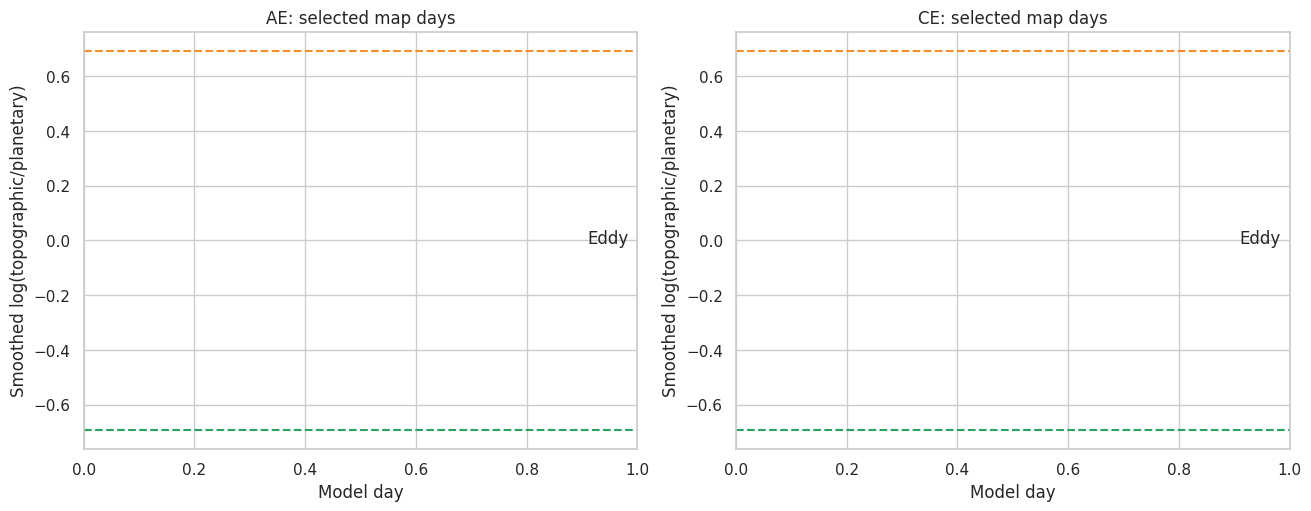

In [8]:
paths=tilt.Paths(); grid=tilt.load_grid(paths.grid,paths.z_r)
data=cases.load_cache(); vertical=tilt.load_vert(paths,dic_form=False)

# Examples: {("AE",356): [1234,1240], ("CE",1927): [5678]}
DAY_OVERRIDES = {}

rows=[]
for cyc,eddy_ids in cases.SELECTED_EDDIES.items():
    for eddy in eddy_ids:
        track=data[data.Cyc.eq(cyc)&data.Eddy.eq(eddy)]
        if track.empty: continue
        days=DAY_OVERRIDES.get((cyc,eddy),cases.suggested_days(track))
        rows.extend({"Cyc":cyc,"Eddy":eddy,"Day":day} for day in days)
selected_days=pd.DataFrame(rows)

fig,axes=plt.subplots(1,2,figsize=(13,5),constrained_layout=True)
for ax,cyc in zip(axes,["AE","CE"]):
    part=data[data.Cyc.eq(cyc)]
    for eddy,track in part.groupby("Eddy"):
        if len(picked):
            ax.plot(track.Day-track.Day.iloc[0],track.topo_plan_ratio_smooth,lw=1,alpha=.65,label=str(int(eddy)))
            marks=selected_days[(selected_days.Cyc.eq(cyc))&(selected_days.Eddy.eq(eddy))]
            picked=track[track.Day.isin(marks.Day)]
            ax.scatter(picked.Day-picked.Day.iloc[0],picked.topo_plan_ratio_smooth,s=25)
    ax.axhline(np.log(2),color=cases.REGIME_COLOURS["topographic"],ls="--")
    ax.axhline(-np.log(2),color=cases.REGIME_COLOURS["planetary"],ls="--")
    ax.set(xlabel="Model day",ylabel="Smoothed log(topographic/planetary)",title=f"{cyc}: selected map days")
    ax.legend(title="Eddy",fontsize=7,ncol=2,frameon=False)
plt.show()

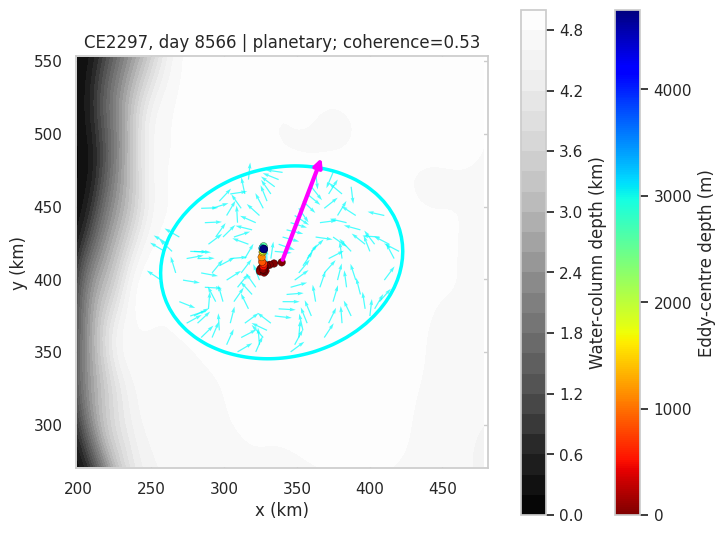

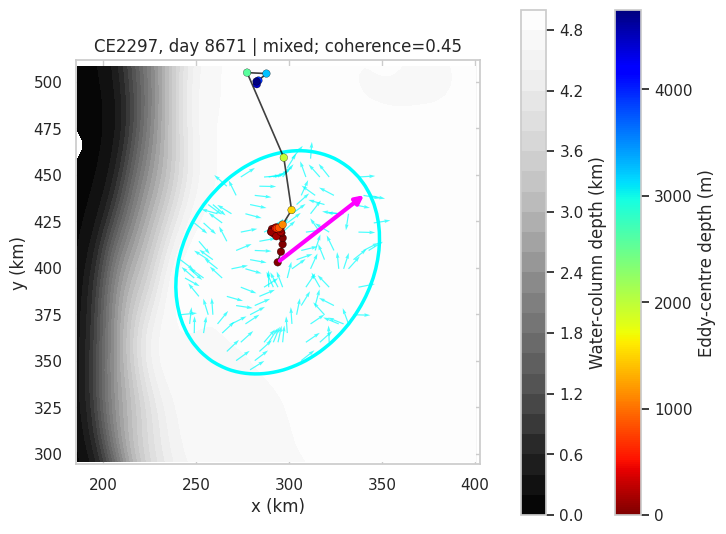

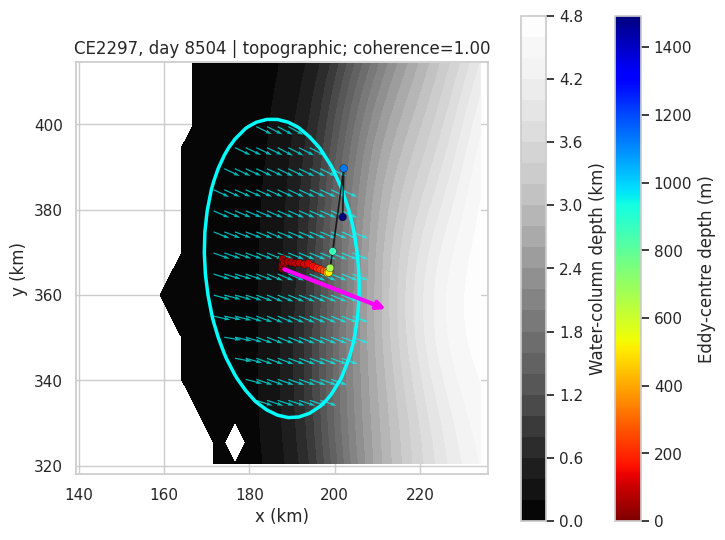

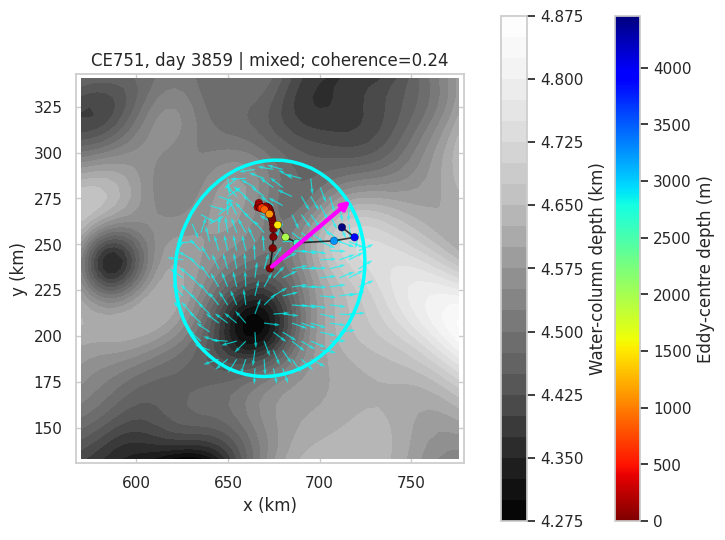

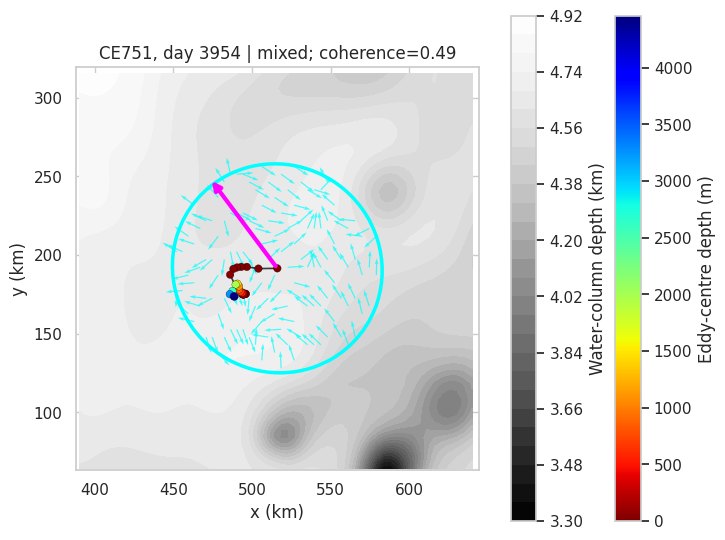

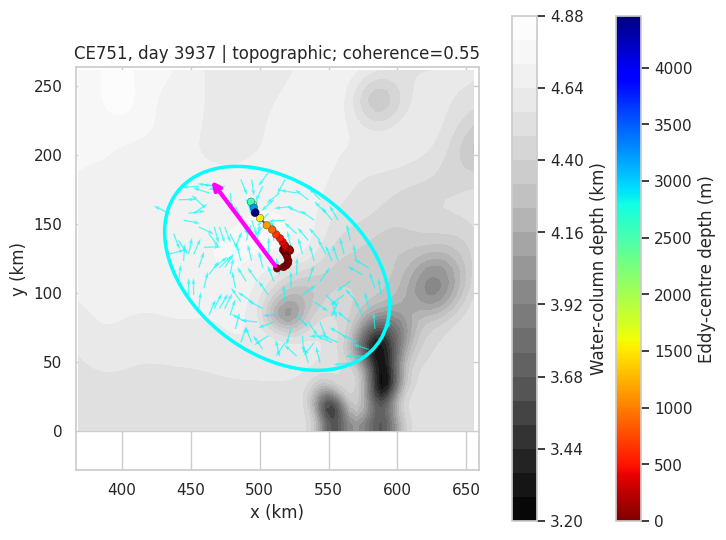

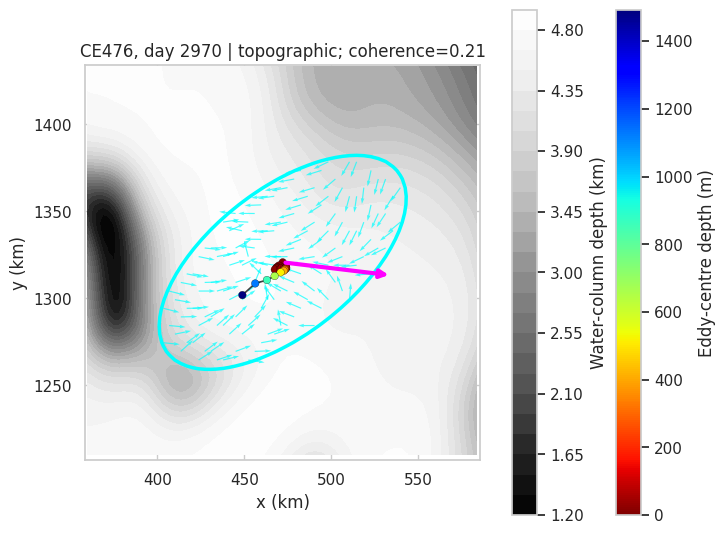

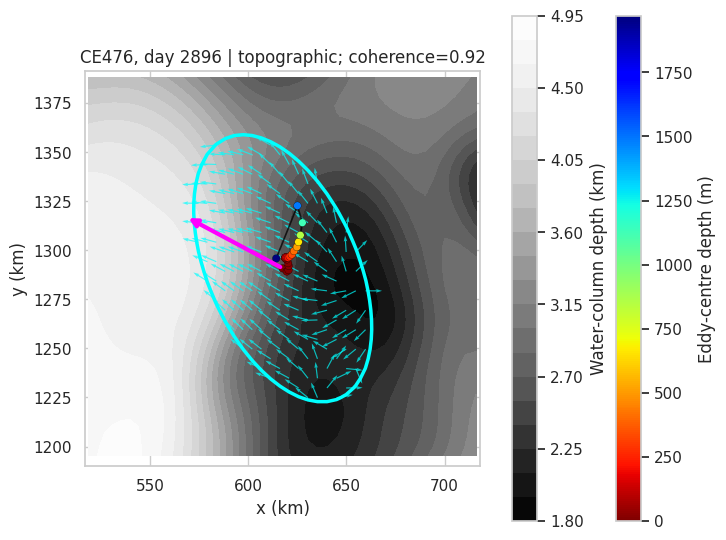

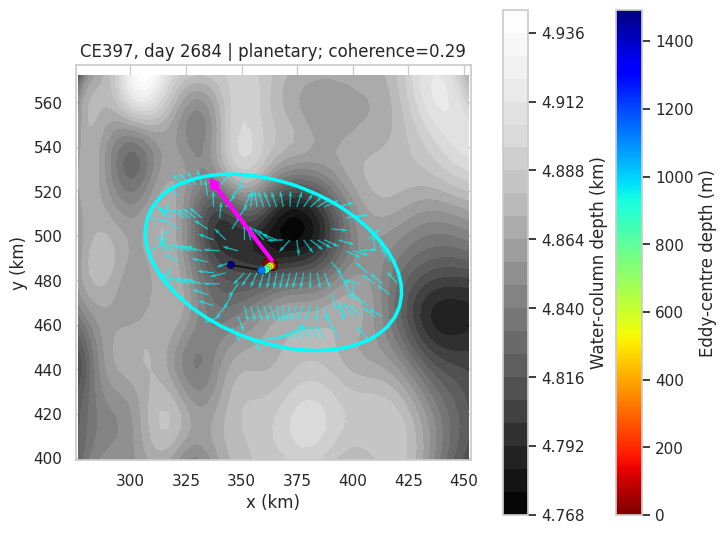

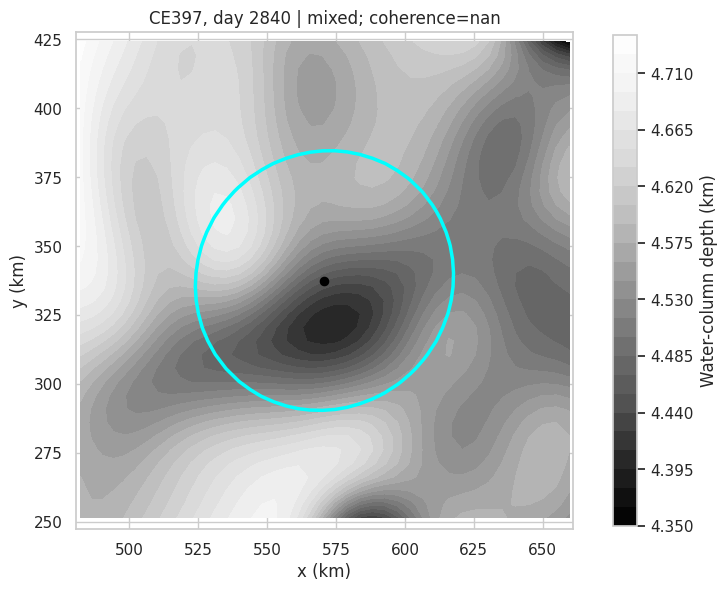

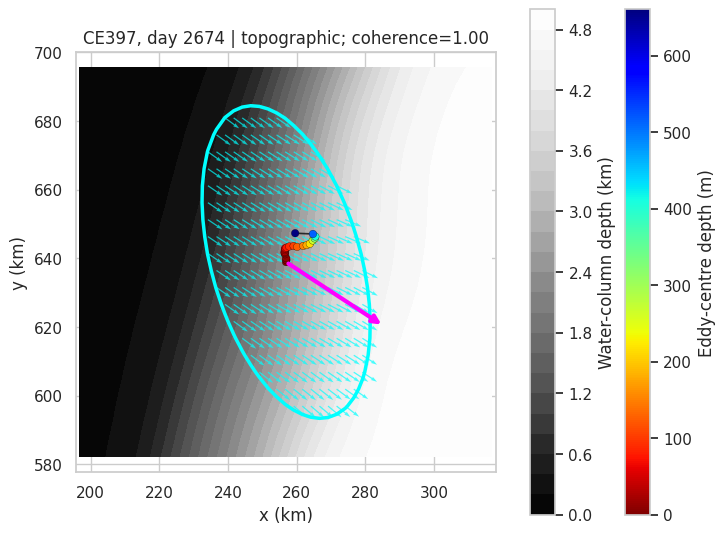

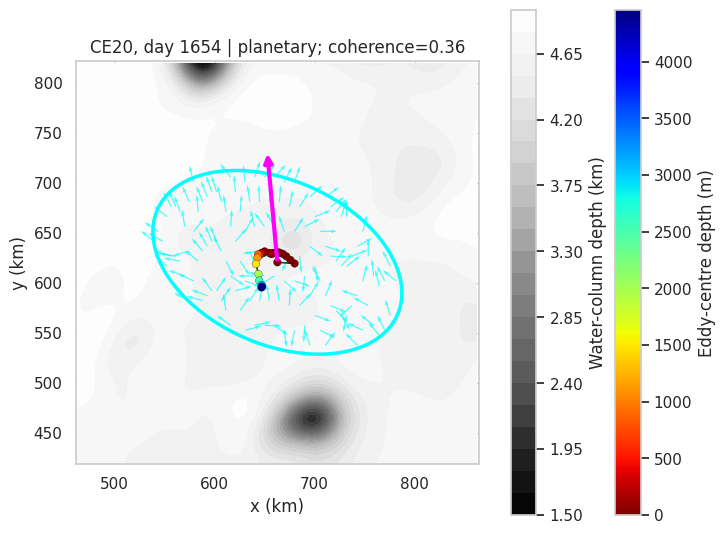

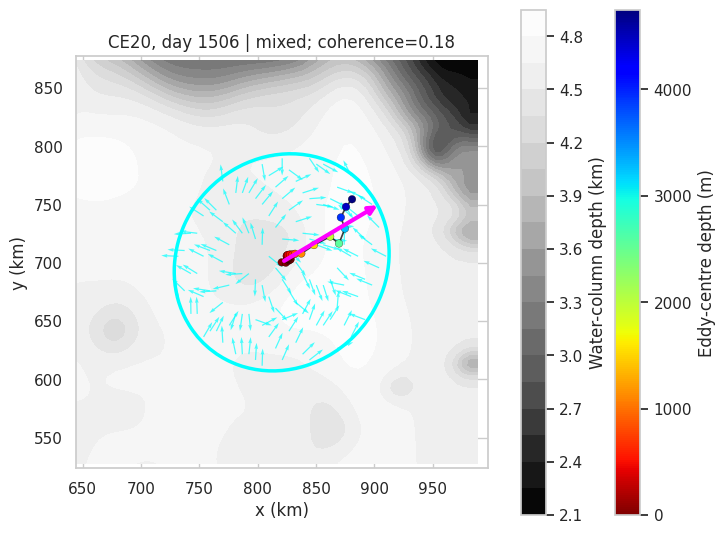

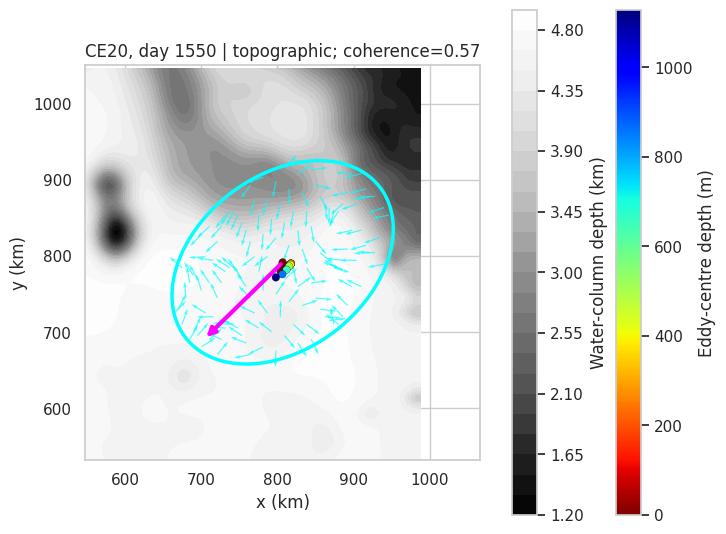

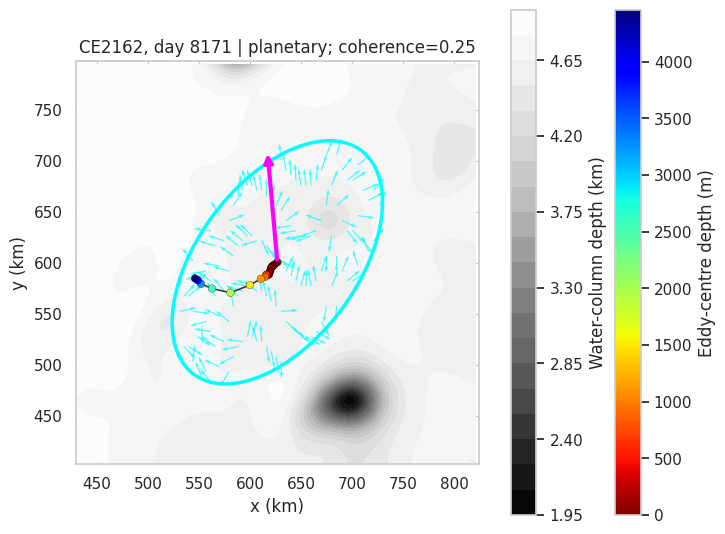

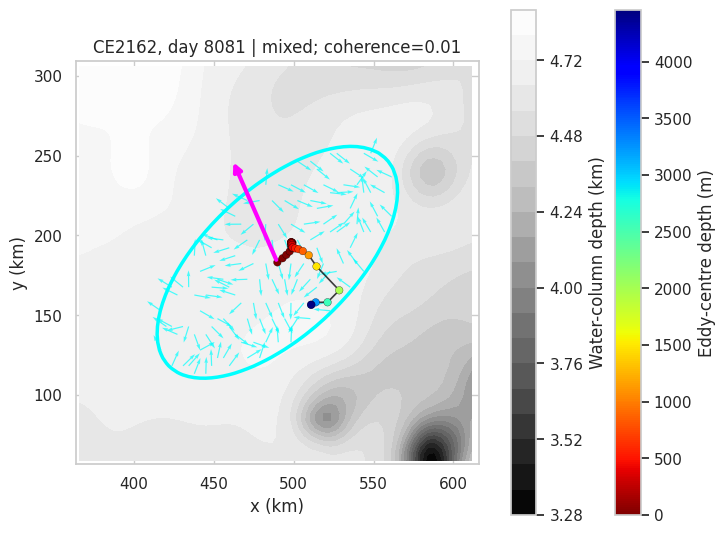

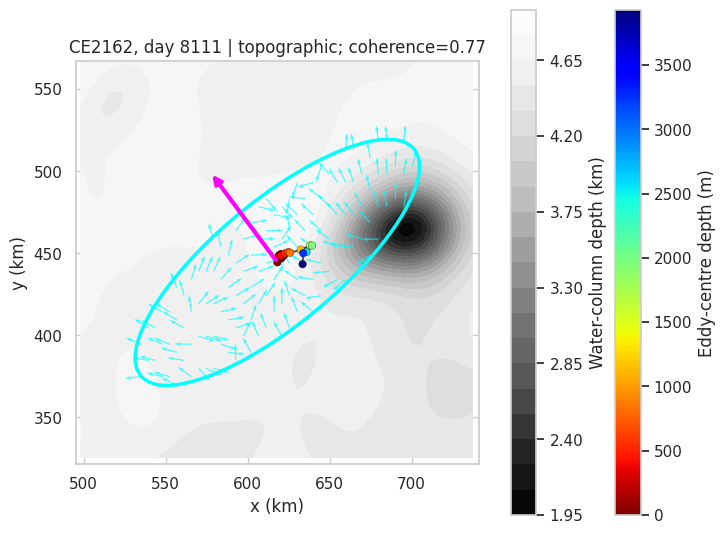

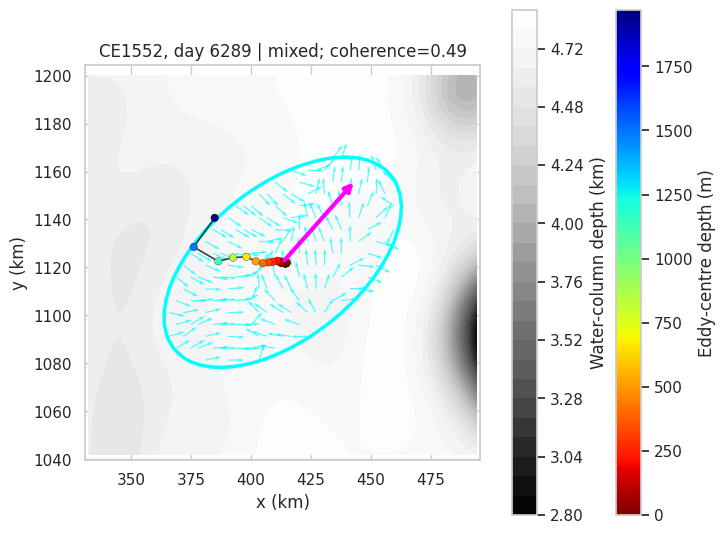

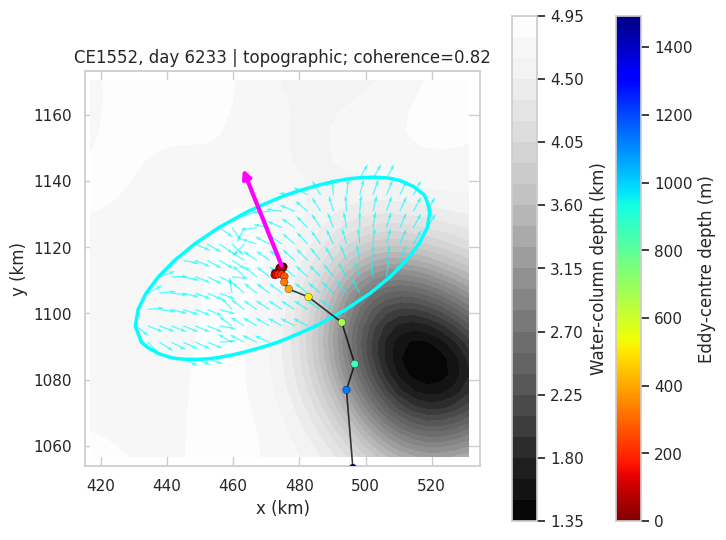

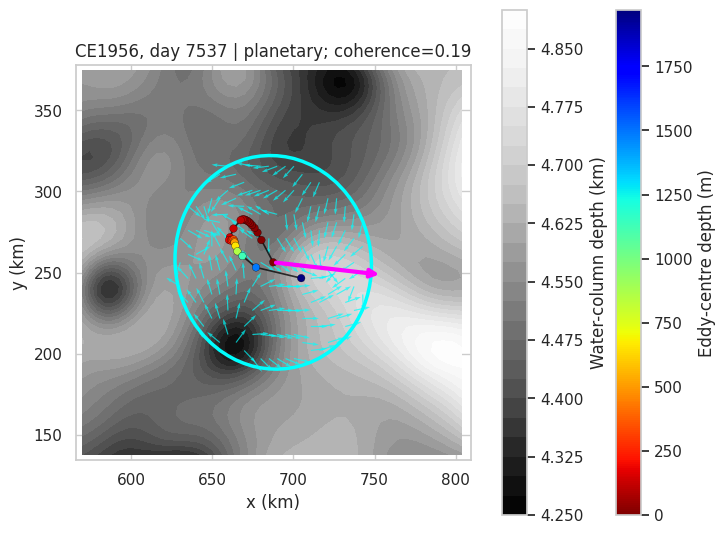

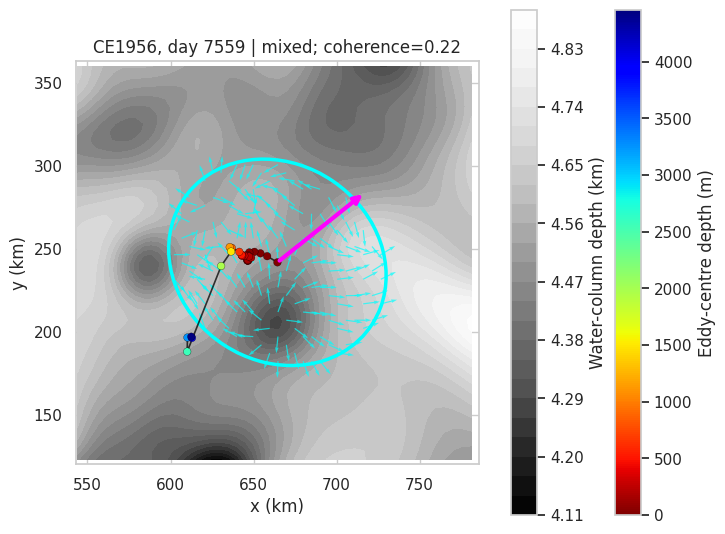

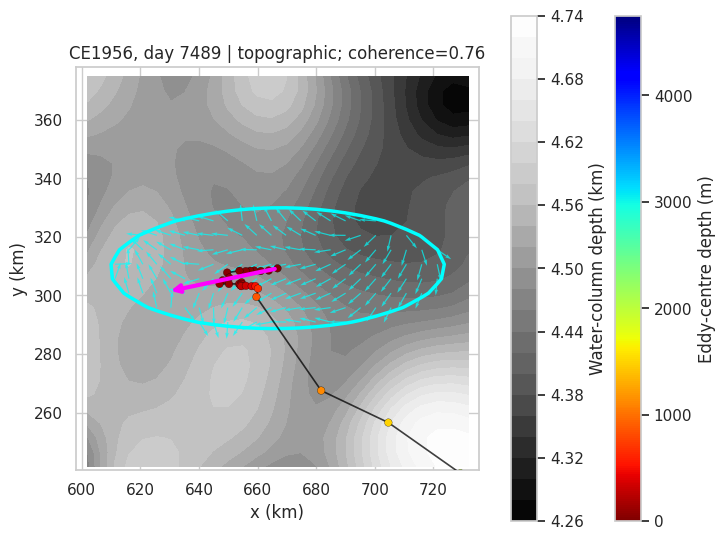

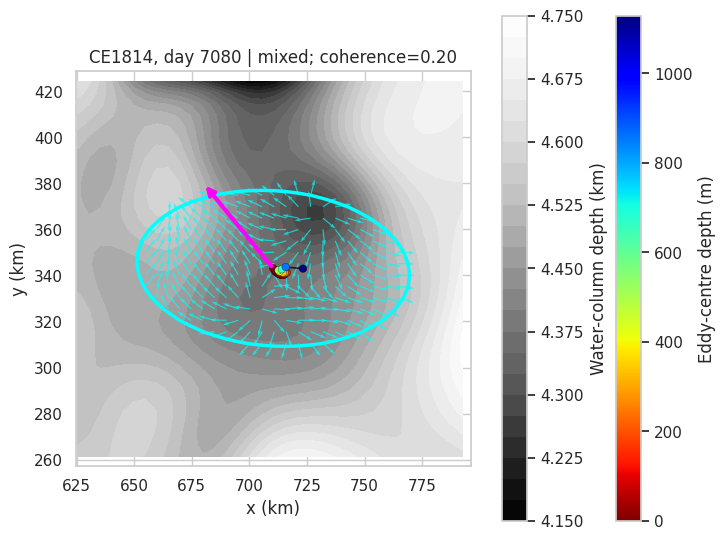

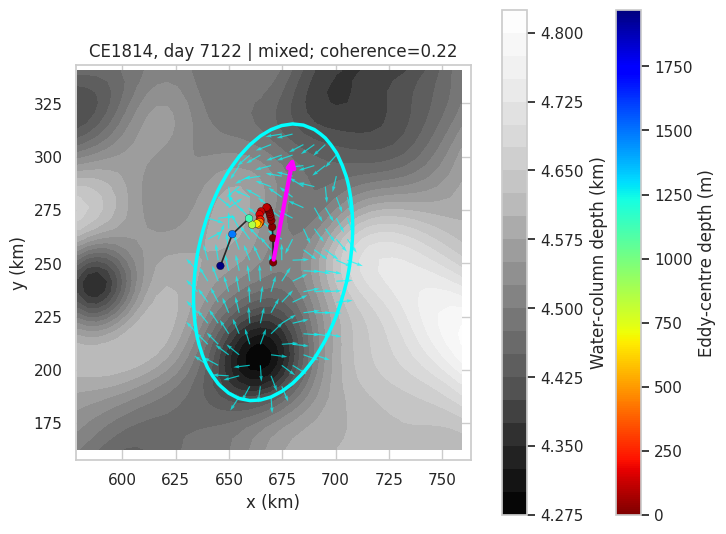

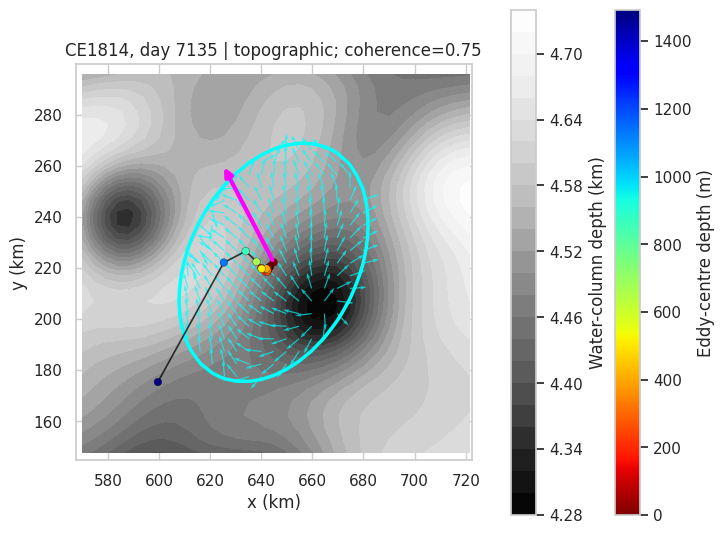

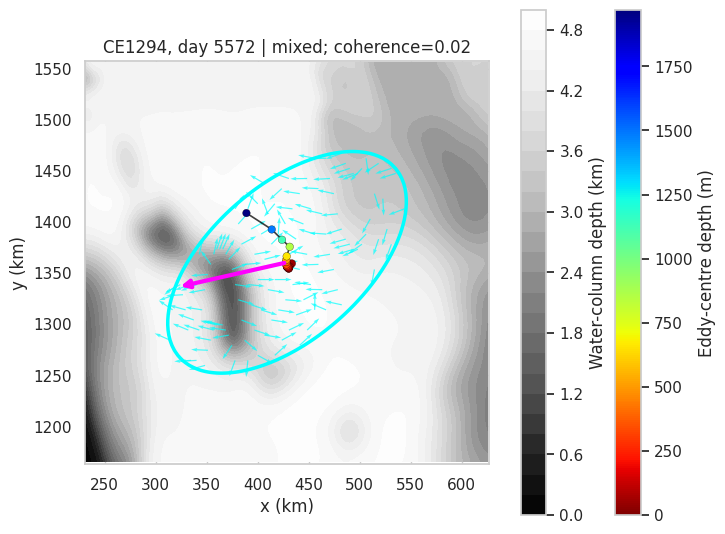

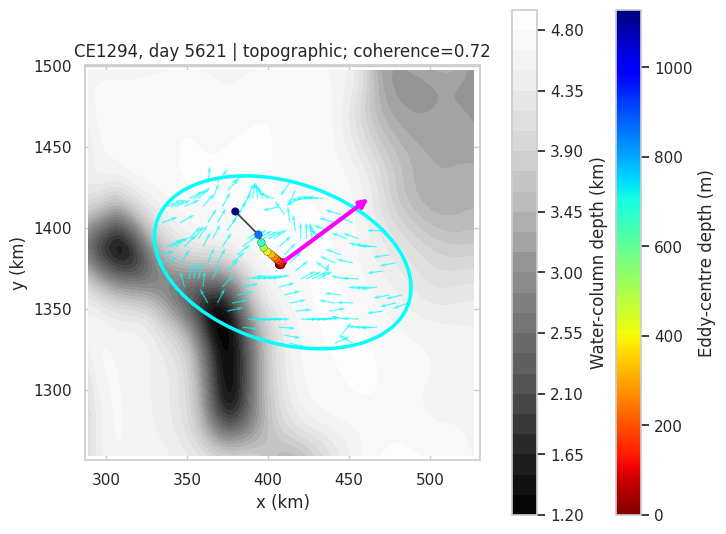

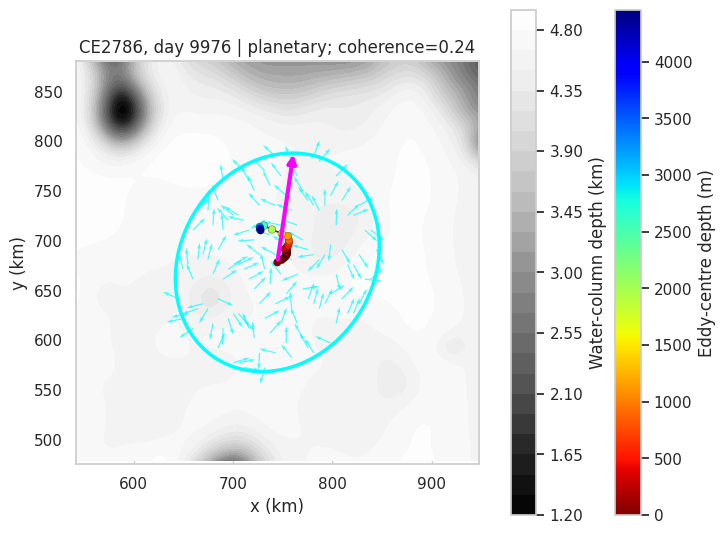

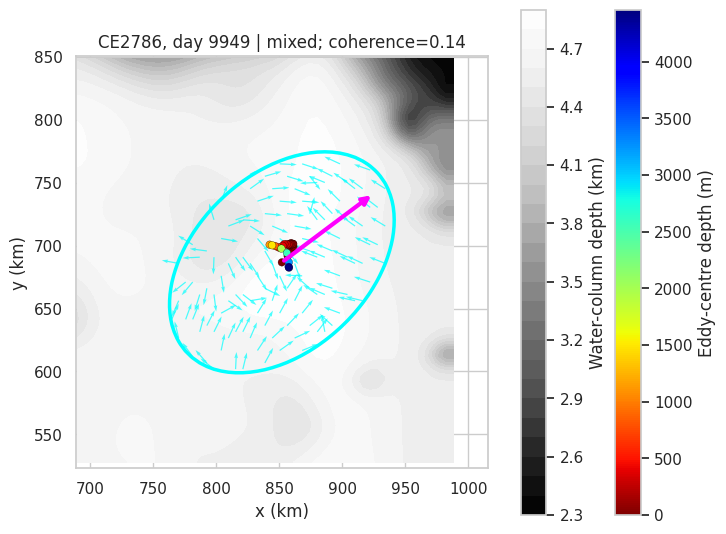

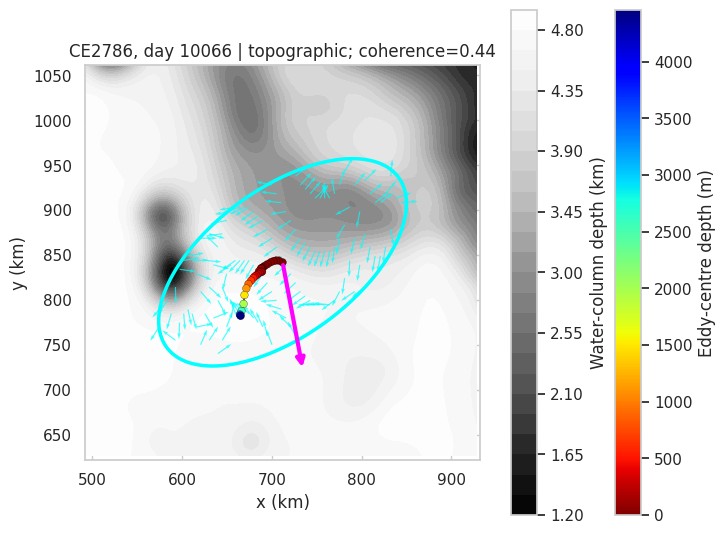

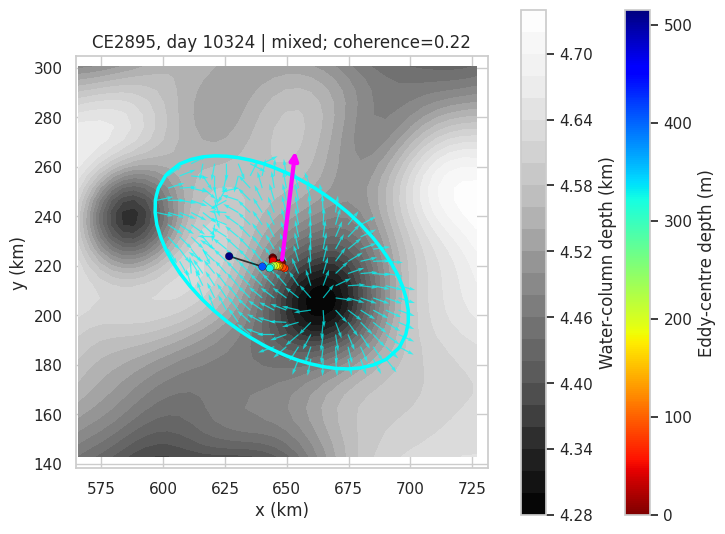

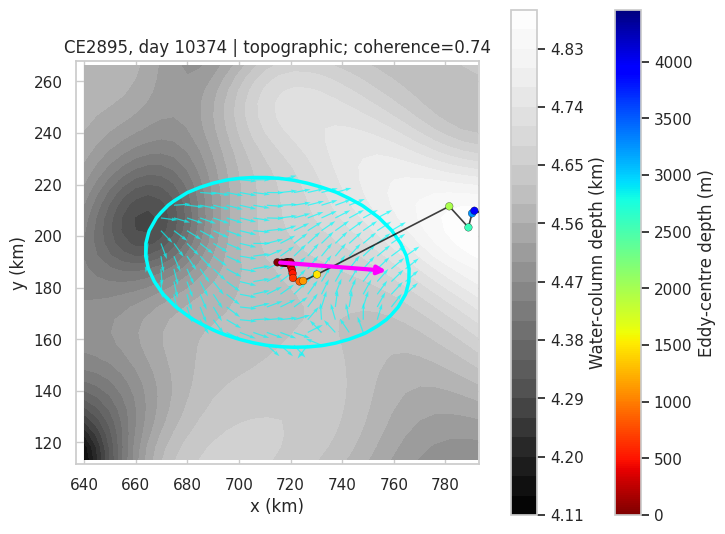

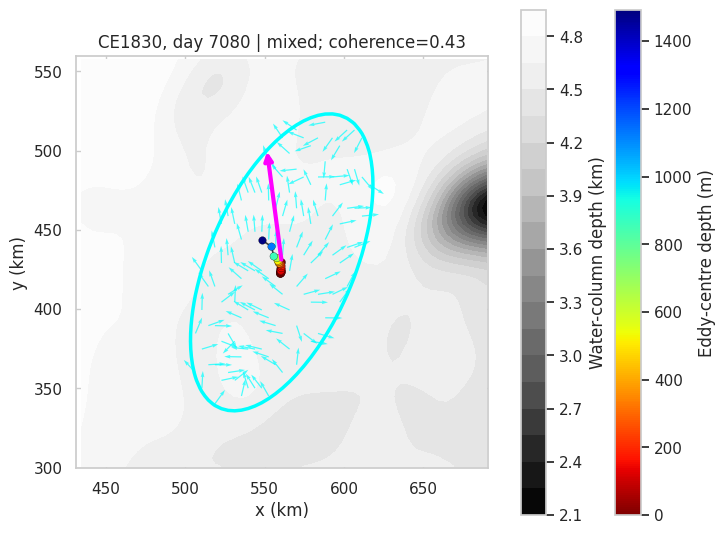

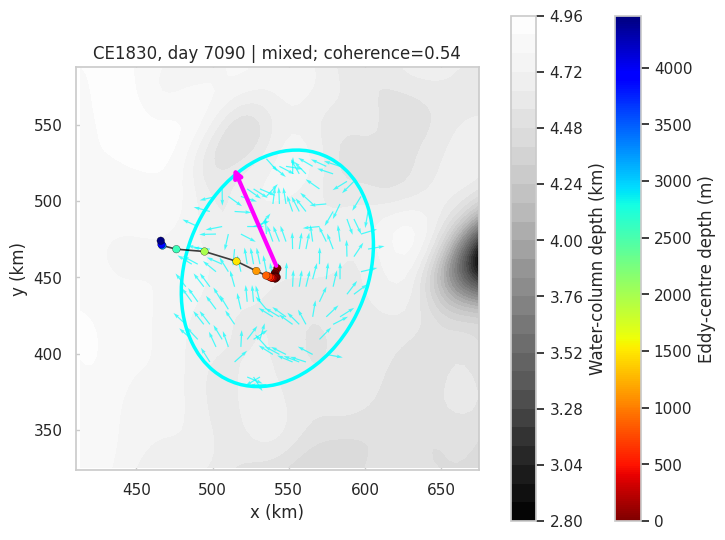

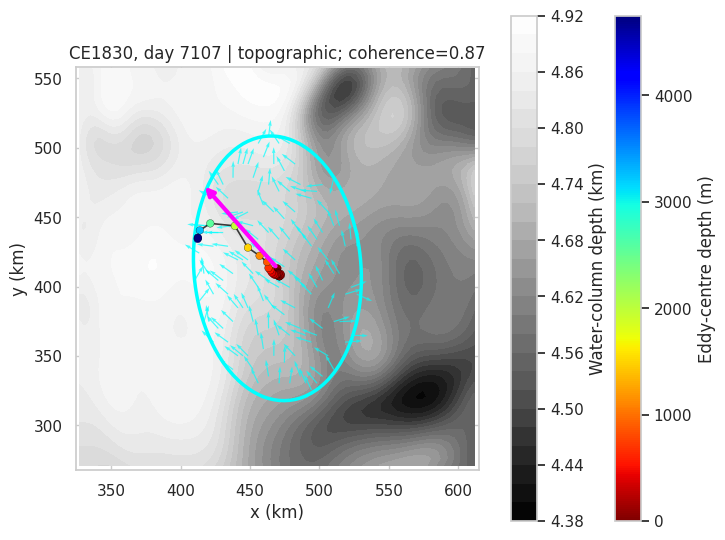

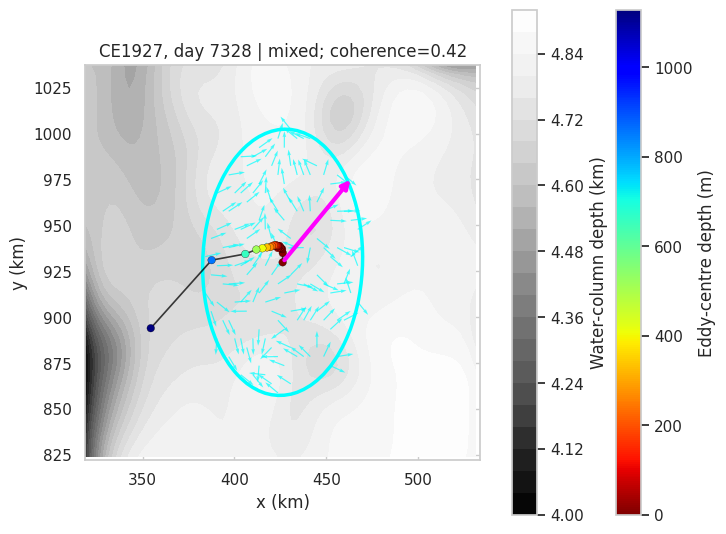

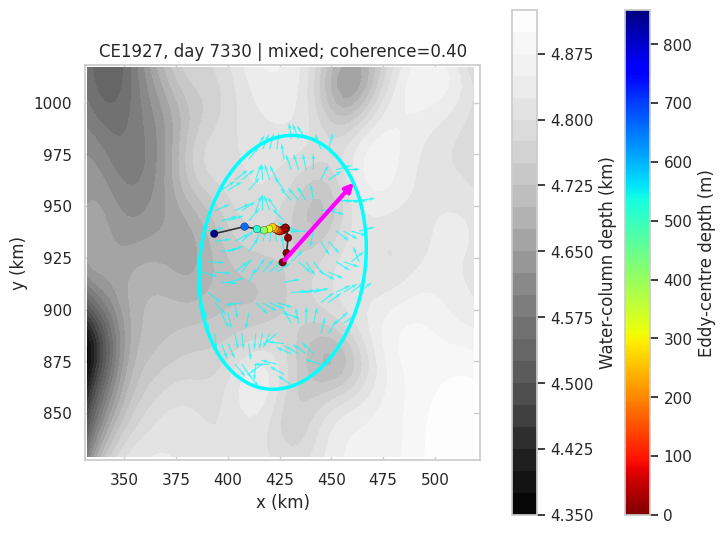

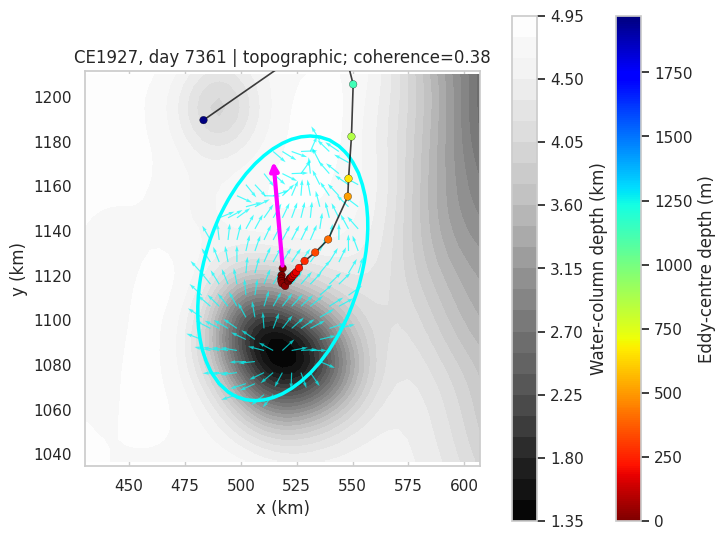

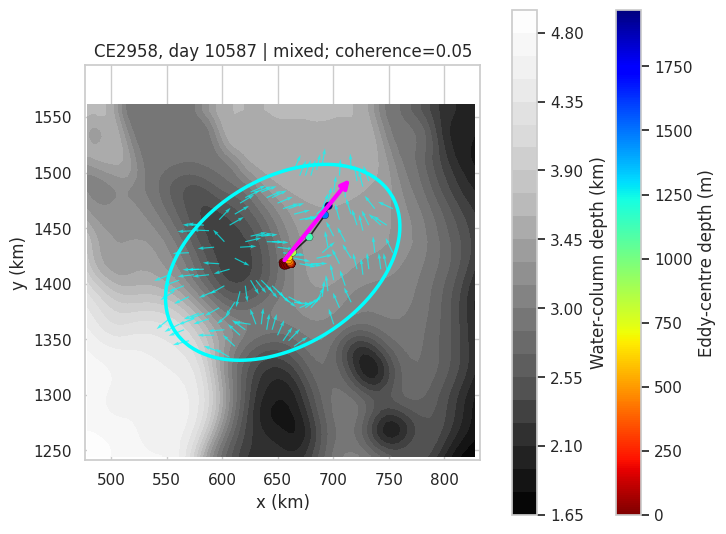

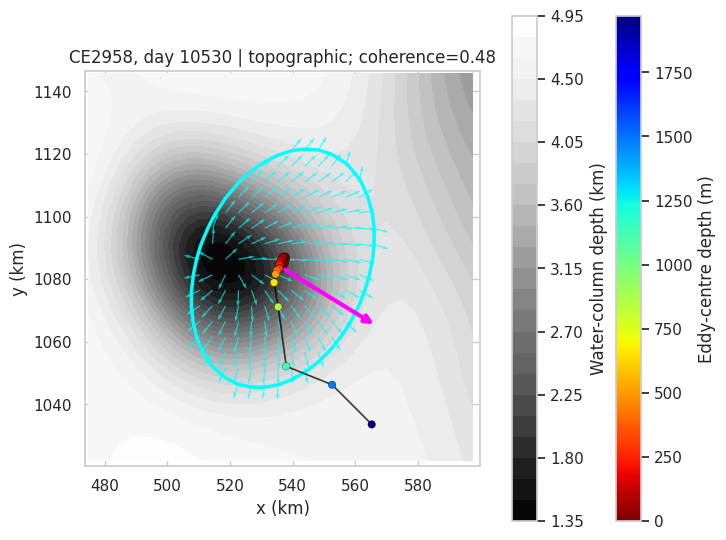

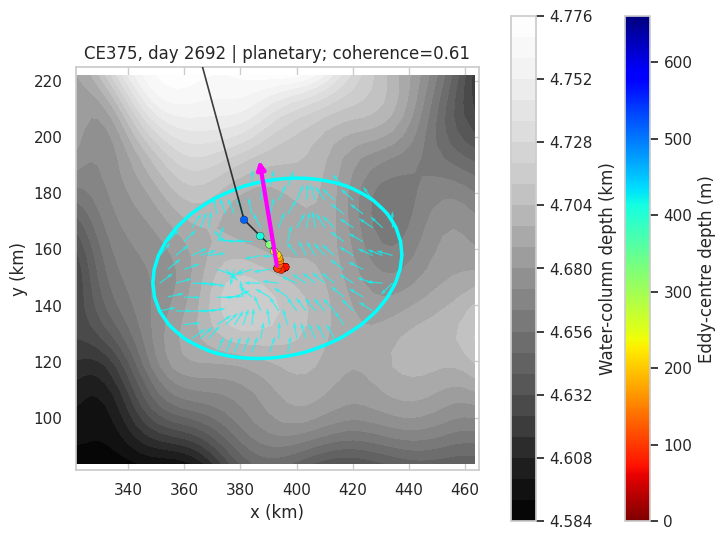

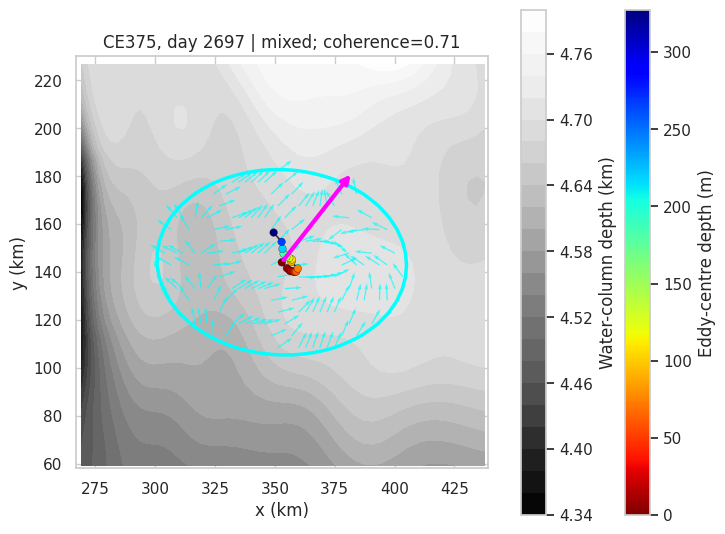

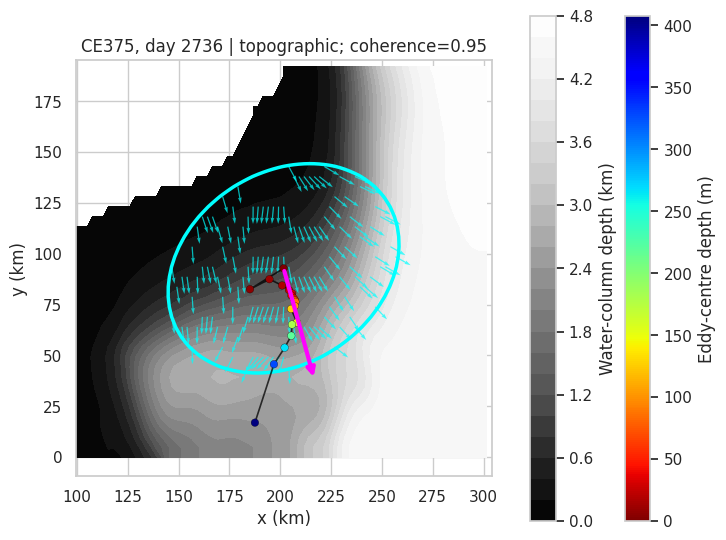

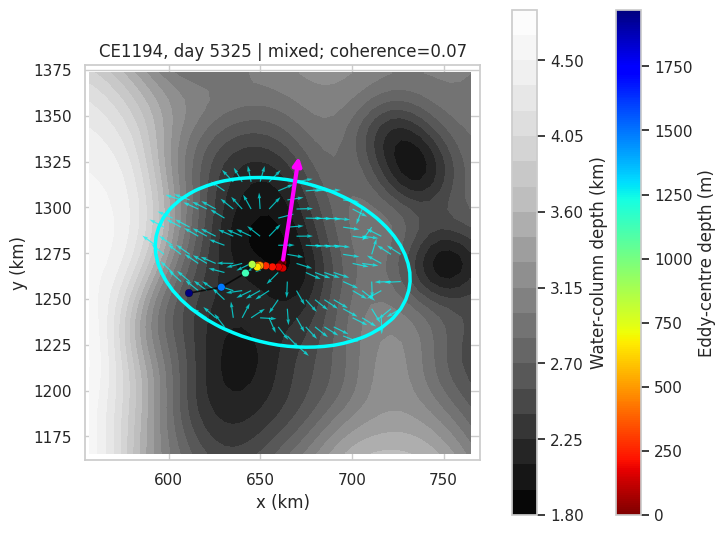

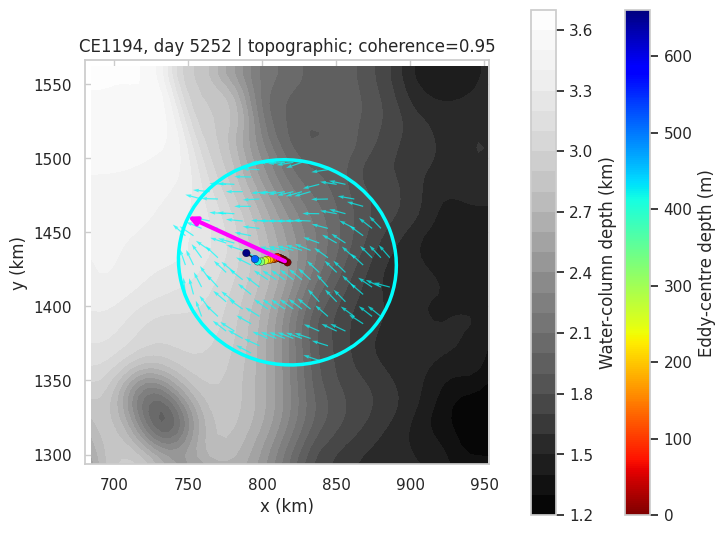

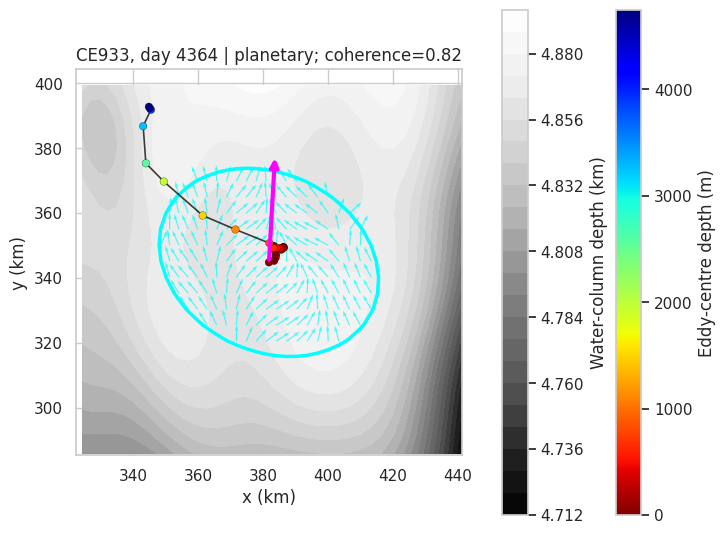

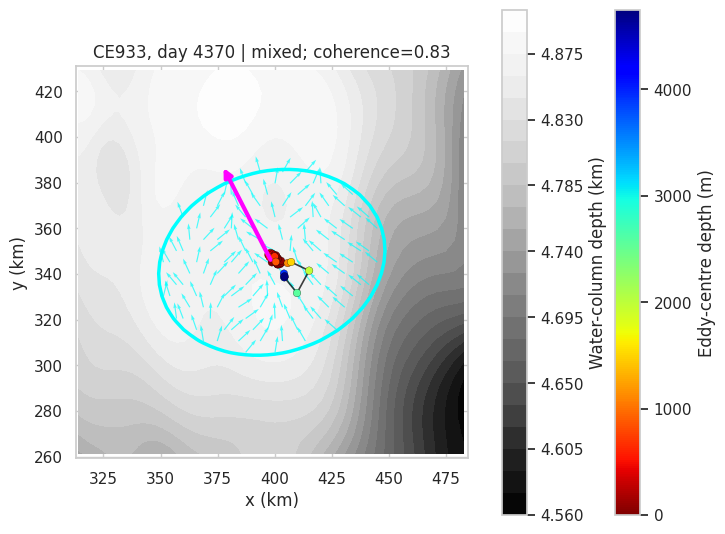

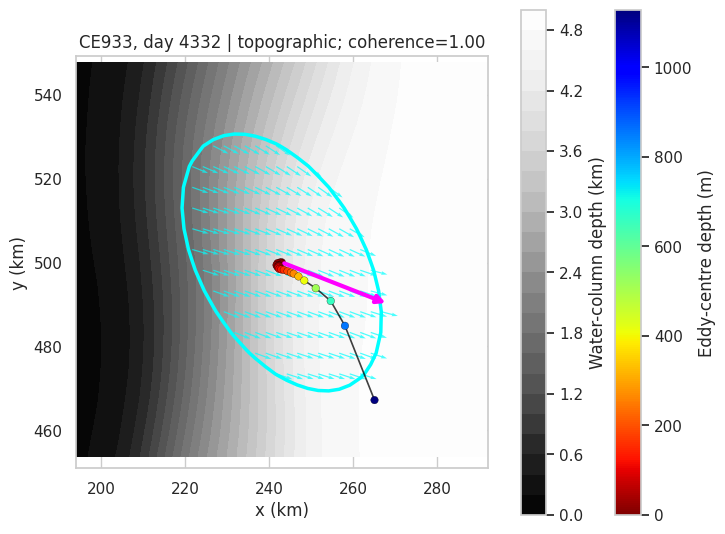

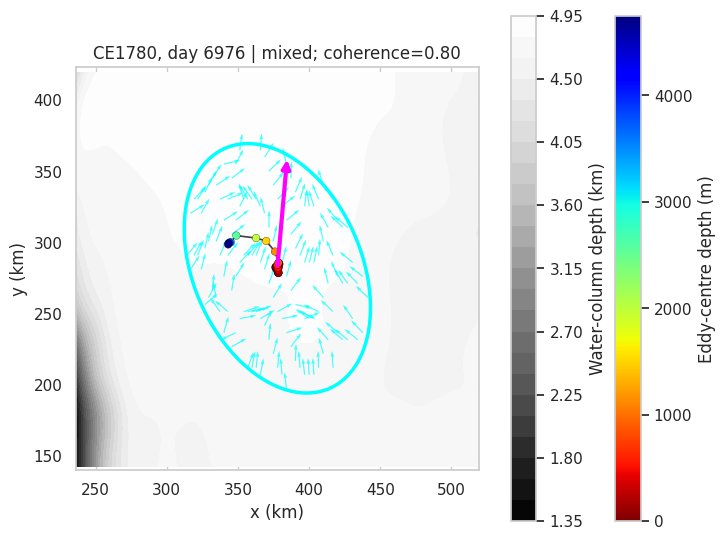

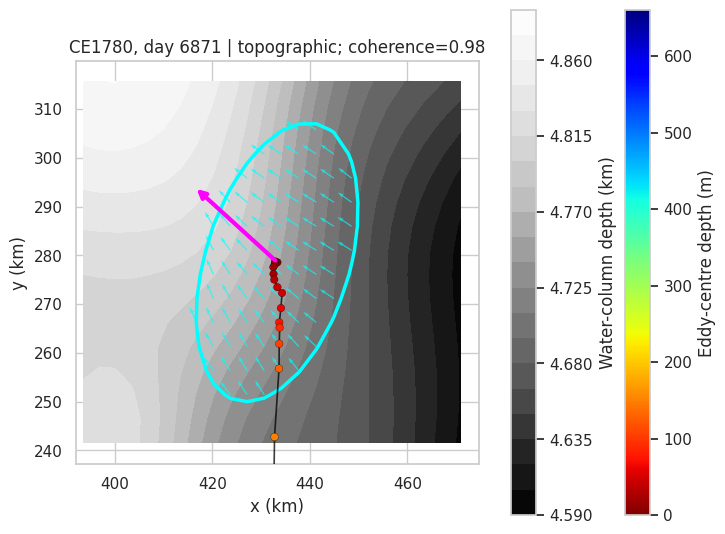

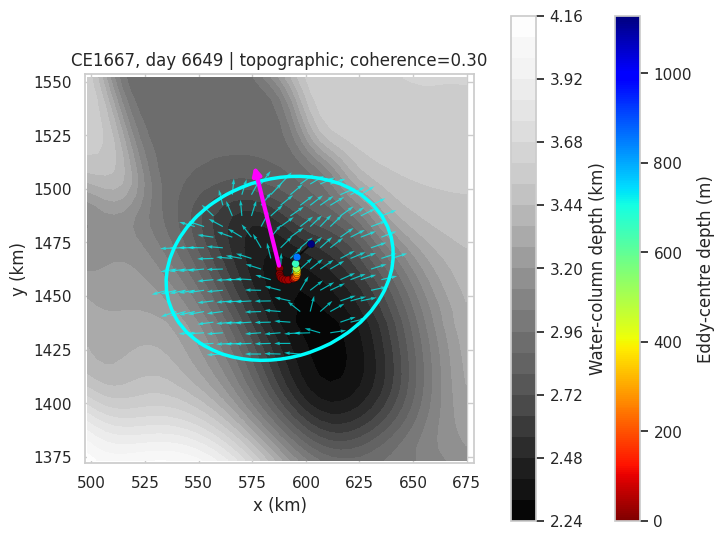

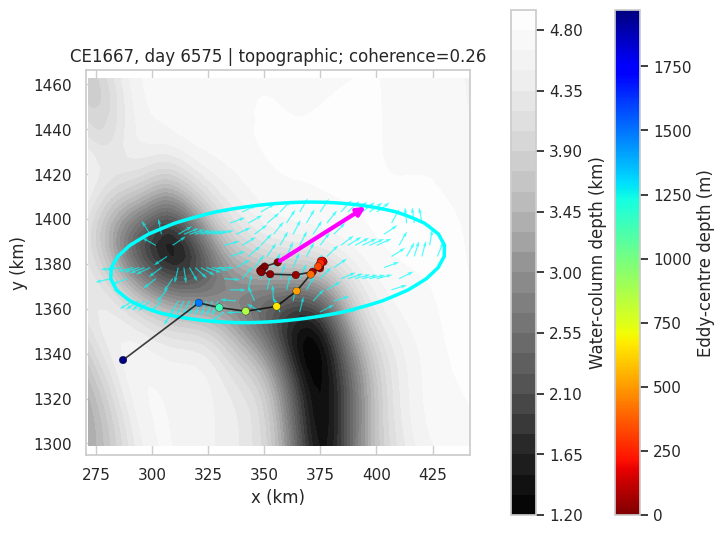

In [9]:
for cyc,eddy,day in selected_days.itertuples(index=False,name=None):
    if cyc =='CE':
        track=data[data.Cyc.eq(cyc)&data.Eddy.eq(eddy)]
        cases.plot_selected_day(track,vertical,grid,day)
        plt.show()

White arrows show local environmental PV-gradient directions inside the `FRAC=1` ellipse. The magenta arrow is their Gaussian-weighted mean. Connected depth-coloured points are the fitted eddy centres down the water column on that day.